<div style="background:linear-gradient(135deg,#022c22 0%,#047857 55%,#10b981 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#d1fae5;font-weight:700;text-transform:uppercase">Chapter 100 · Regression Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Predicting Ames House Prices</div>
  <div style="font-size:15px;color:#f0fdf4;max-width:740px;line-height:1.6">A complete regression project in 12 steps: from a raw, messy CSV to a cleaned, transformed, fitted, diagnosed, and interpreted model, with every table and chart explained.</div>
  <div style="margin-top:16px;font-size:13px;color:#d1fae5">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Predicting Ames House Prices: an end-to-end case study
This notebook runs a real regression project from a raw, messy file to a validated, interpreted model, following a **12-step method**. The data is deliberately dirty (duplicate rows, inconsistent categories, three date formats, structural and genuine missing values, a skewed target, and outliers), exactly what you meet in practice. We lean on `pandas`, `seaborn`/`matplotlib`, `statsmodels`, and `scikit-learn`, and explain every table and picture along the way.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
ORG="#059669"; DEEP="#047857"; LIGHT="#6ee7b7"; EM="#059669"; EMDEEP="#047857"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')
import statsmodels.api as sm; import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score; from sklearn.linear_model import LinearRegression
pd.set_option('display.max_columns', 40)

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 1 &#183; DEFINE THE OBJECTIVE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What are we trying to learn, and for whom?</div>
<div style="color:#4a5578;margin-top:6px">A model with no question is a solution looking for a problem.</div>
</div>

**Objective.** Predict a home's **sale price** from its characteristics, and identify *which* characteristics drive price the most.

**Why / for whom.** A real-estate agent pricing a new listing, a homeowner deciding which renovation pays off, a buyer checking whether an asking price is fair, or a county assessor valuing properties at scale.

**Success looks like:** a model that (a) predicts price with useful accuracy, (b) has *trustworthy* coefficients we can read as dollar drivers, and (c) passes its regression diagnostics or is honestly corrected where it does not. Getting there is steps 2-12.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 2 &#183; COLLECT THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Where data comes from, and how Python reads each source</div>
<div style="color:#4a5578;margin-top:6px">Ours is a CSV; in the wild it could be any of these.</div>
</div>

Real projects pull data from many places. pandas has a one-line reader for almost all of them:

| Source | Typical format | Python (pandas) |
|---|---|---|
| Flat file export | CSV / TSV | `pd.read_csv('file.csv')` |
| Spreadsheet | Excel .xlsx | `pd.read_excel('file.xlsx', sheet_name=...)` |
| Relational database | SQL (Postgres, MySQL, SQLite) | `pd.read_sql('SELECT ...', engine)` with SQLAlchemy |
| Web API | JSON | `requests.get(url).json()` then `pd.json_normalize(...)` |
| Web page (tables) | HTML | `pd.read_html(url)` returns a list of DataFrames |
| Web scraping (general) | HTML | `requests` + `BeautifulSoup` to parse, then build a DataFrame |
| Columnar / big data | Parquet | `pd.read_parquet('file.parquet')` (fast, typed) |

Whatever the source, the goal is the same: land the data in a **DataFrame**. From there the rest of the pipeline is identical. Our source is a CSV exported from the county records, so:

In [3]:
# The one-liners for other sources (commented; we only have the CSV here):
# import sqlalchemy; eng = sqlalchemy.create_engine('sqlite:///homes.db'); df = pd.read_sql('SELECT * FROM sales', eng)
# import requests; df = pd.json_normalize(requests.get(API_URL).json()['results'])
# tables = pd.read_html('https://example.com/prices'); df = tables[0]
try:
    homes = pd.read_csv('../../data/ames_housing.csv')
except FileNotFoundError:
    homes = pd.read_csv(BASE + 'ames_housing.csv')
print('loaded', homes.shape)

loaded (610, 16)


<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 3 &#183; INSPECT THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Meet the data before you touch it</div>
<div style="color:#4a5578;margin-top:6px">shape, dtypes, head, describe, and the missing-value map.</div>
</div>

In [4]:
print('rows x cols:', homes.shape)
homes.head(4)

rows x cols: (610, 16)


,house_id,neighborhood,lot_area,lot_frontage,year_built,gr_liv_area,bedrooms,full_bath,central_air,fireplace_qual,garage_yr_built,pool_qc,kitchen_qual,exterior_color,sale_date,sale_price
0,1220,Somerset,6339,58.0,1955,885,1,1,Y,NaN,1953.0,NaN,Po,brick,09/07/1955,146251.0
1,1169,OldTown,9227,62.0,1940,1516,4,2,Yes,TA,1945.0,NaN,TA,blue,1940-03-19,99200.0
2,1049,OldTown,12262,36.0,1950,1784,4,2,Y,Gd,1955.0,NaN,Po,beige,19-Dec-1950,135344.0
3,1270,BrookSide,7592,48.0,1945,1509,4,3,Y,NaN,1950.0,NaN,Ex,blue,1945-02-25,180715.0


In [5]:
homes.info()

<class 'pandas.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   house_id         610 non-null    int64  
 1   neighborhood     610 non-null    str    
 2   lot_area         610 non-null    int64  
 3   lot_frontage     512 non-null    float64
 4   year_built       610 non-null    int64  
 5   gr_liv_area      610 non-null    int64  
 6   bedrooms         610 non-null    int64  
 7   full_bath        610 non-null    int64  
 8   central_air      610 non-null    str    
 9   fireplace_qual   320 non-null    str    
 10  garage_yr_built  581 non-null    float64
 11  pool_qc          6 non-null      str    
 12  kitchen_qual     610 non-null    str    
 13  exterior_color   610 non-null    str    
 14  sale_date        610 non-null    str    
 15  sale_price       607 non-null    float64
dtypes: float64(3), int64(6), str(7)
memory usage: 76.4 KB


In [6]:
# Numeric summary, and the missing-value map
display(homes.describe().round(0))
miss = homes.isna().sum().sort_values(ascending=False)
print('\nMissing values per column:'); print(miss[miss>0].to_string())

,house_id,lot_area,lot_frontage,year_built,gr_liv_area,bedrooms,full_bath,garage_yr_built,sale_price
count,610.0,610.0,512.0,610.0,610.0,610.0,610.0,581.0,607.0
mean,1298.0,9687.0,71.0,1953.0,1508.0,3.0,2.0,1955.0,184147.0
std,174.0,3238.0,21.0,31.0,501.0,1.0,1.0,31.0,64748.0
min,1000.0,3246.0,21.0,1900.0,480.0,1.0,1.0,1900.0,68872.0
25%,1145.0,7466.0,58.0,1928.0,1202.0,2.0,1.0,1929.0,138462.0
50%,1298.0,9108.0,70.0,1952.0,1482.0,3.0,2.0,1953.0,172879.0
75%,1449.0,11362.0,85.0,1979.0,1775.0,4.0,2.0,1981.0,216536.0
max,1599.0,31300.0,144.0,2009.0,5642.0,6.0,4.0,2010.0,518293.0



Missing values per column:
pool_qc            604
fireplace_qual     290
lot_frontage        98
garage_yr_built     29
sale_price           3


Three kinds of trouble are already visible. **(1) Missing values** in five columns, but of two very different kinds: `pool_qc` (604) and `fireplace_qual` (290) are missing because *most homes have no pool or fireplace* (structural), whereas `lot_frontage` (98) is *genuinely unknown* and `sale_price` (3) is our target, which we cannot impute. **(2) Inconsistent categories**, look:


In [7]:
print('central_air :', homes.central_air.value_counts().to_dict())
print('kitchen_qual:', homes.kitchen_qual.value_counts().to_dict())
print('ext color   :', homes.exterior_color.value_counts().to_dict())
print('duplicate house_id rows:', homes.house_id.duplicated().sum())
print('sale_date formats:', homes.sale_date.dropna().head(4).tolist())

central_air : {'Y': 550, 'N': 52, 'Yes': 8}
kitchen_qual: {'Po': 112, 'TA': 111, 'Ex': 106, 'Gd': 106, 'Fa': 101, 'fa': 13, 'FA': 9, 'EX': 8, 'gd': 8, 'ex': 7, 'Ta': 7, 'GD': 7, 'po': 6, 'ta': 5, 'PO': 4}
ext color   : {'white': 155, 'beige': 147, 'gray': 119, 'brick': 80, 'blue': 49, 'Beige': 13, 'WHITE': 11, 'White': 9, 'Gray': 7, 'Blue': 6, 'Brick': 6, 'grey': 5, 'Grey': 3}
duplicate house_id rows: 10
sale_date formats: ['09/07/1955', '1940-03-19', '19-Dec-1950', '1945-02-25']


**(3) Data-entry chaos.** `central_air` mixes `Y` and `Yes`; `kitchen_qual` and `exterior_color` come in every mix of upper/lower case (`Po`, `po`, `PO`); there are **10 duplicate house IDs**; and `sale_date` arrives in *three different formats*. None of this is unusual, and all of it must be fixed before modeling.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 4 &#183; CLEAN THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fix each problem deliberately, and record what you did</div>
<div style="color:#4a5578;margin-top:6px">Drop, deduplicate, standardize, parse, impute.</div>
</div>

In [8]:
df = homes.copy()
n0 = len(df)
# (a) the target cannot be imputed -> drop rows with no sale_price
df = df.dropna(subset=['sale_price'])
# (b) remove duplicate listings (same house_id)
df = df.drop_duplicates(subset='house_id')
print(f'rows: {n0} -> {len(df)}  (dropped {n0-len(df)}: 3 missing target + 10 duplicates)')

rows: 610 -> 597  (dropped 13: 3 missing target + 10 duplicates)


In [9]:
# (c) standardize inconsistent categories
df['central_air'] = df['central_air'].replace({'Yes':'Y'}).map({'Y':1, 'N':0})
df['exterior_color'] = df['exterior_color'].str.strip().str.lower().replace({'grey':'gray'})
up = lambda s: s.astype(str).str.strip().str.upper()   # 'po','PO','Po' -> 'PO'
QMAP = {'PO':1, 'FA':2, 'TA':3, 'GD':4, 'EX':5}         # ordinal quality scale
df['kitchen_qual'] = up(df['kitchen_qual']).map(QMAP)
print('kitchen_qual now:', sorted(df.kitchen_qual.dropna().unique()), ' ext colors:', sorted(df.exterior_color.unique()))

kitchen_qual now: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]  ext colors: ['beige', 'blue', 'brick', 'gray', 'white']


In [10]:
# (d) structural missing -> a 'none' category and a has_* flag (NOT an error, it is information)
df['fireplace_ord'] = up(df['fireplace_qual'].fillna('NONE')).map({**QMAP, 'NONE':0})
df['has_fireplace'] = df['fireplace_qual'].notna().astype(int)
df['has_pool']     = df['pool_qc'].notna().astype(int)
df['has_garage']   = df['garage_yr_built'].notna().astype(int)
# (e) genuine missing -> impute lot_frontage with the neighborhood median (smarter than a global median)
before = df['lot_frontage'].isna().sum()
df['lot_frontage'] = df.groupby('neighborhood')['lot_frontage'].transform(lambda s: s.fillna(s.median()))
print(f'lot_frontage: imputed {before} values by neighborhood median')

lot_frontage: imputed 95 values by neighborhood median


In [11]:
# (f) parse the three date formats in one call, then engineer house age
dt = pd.to_datetime(df['sale_date'], format='mixed', errors='coerce')
df['sale_year'] = dt.dt.year.fillna(dt.dt.year.median())
df['house_age'] = (df['sale_year'] - df['year_built']).clip(lower=0)
print('unparseable dates:', dt.isna().sum(), '| any missing left in modeling cols:',
      df[['sale_price','gr_liv_area','kitchen_qual','lot_frontage','house_age']].isna().sum().sum())

unparseable dates: 0 | any missing left in modeling cols: 0


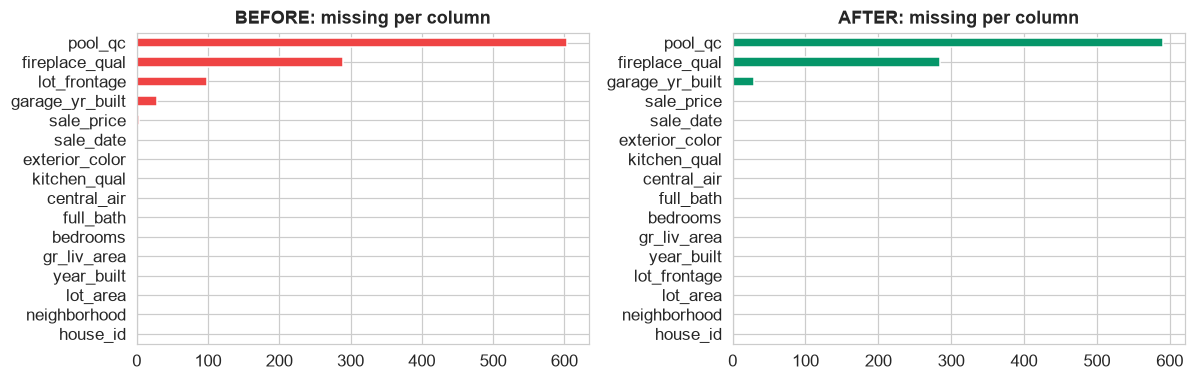

In [12]:
# Confirm the clean-up: missing before vs after
fig, ax = plt.subplots(1, 2, figsize=(11,3.6))
homes.isna().sum().sort_values().plot(kind='barh', ax=ax[0], color=RED); ax[0].set_title('BEFORE: missing per column')
df[[c for c in df.columns if c in homes.columns]].isna().sum().sort_values().plot(kind='barh', ax=ax[1], color=GREEN)
ax[1].set_title('AFTER: missing per column'); plt.tight_layout(); plt.show()

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 5 &#183; VISUALIZE THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Look before you model</div>
<div style="color:#4a5578;margin-top:6px">Histogram, box-and-whisker, and a heatmap tell you the shape, the spread, and the relationships.</div>
</div>

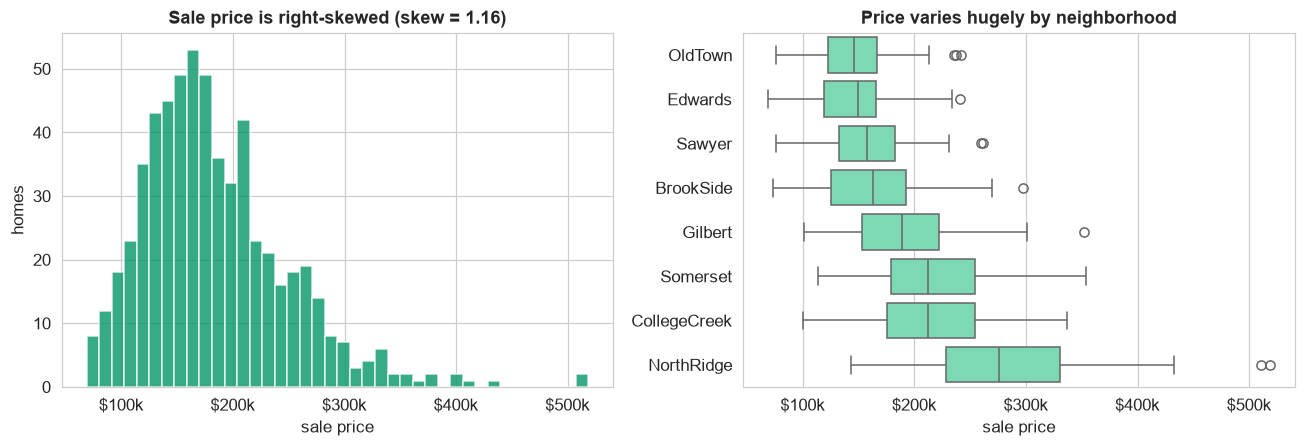

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12,4.2))
ax[0].hist(df.sale_price, bins=40, color=EM, alpha=0.8)
ax[0].set(title=f'Sale price is right-skewed (skew = {df.sale_price.skew():.2f})', xlabel='sale price', ylabel='homes')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k'))
order = df.groupby('neighborhood').sale_price.median().sort_values().index
sns.boxplot(data=df, y='neighborhood', x='sale_price', order=order, ax=ax[1], color=LIGHT)
ax[1].set(title='Price varies hugely by neighborhood', xlabel='sale price', ylabel='')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k'))
plt.tight_layout(); plt.show()

The histogram is **right-skewed** (a long tail of expensive homes, skew 1.16), a red flag for the equal-variance and normality assumptions, which we will fix with a log transform in step 6. The box plots show **location dominates**: median price roughly doubles from the cheapest neighborhood to the priciest, and the whiskers/dots flag some high-price outliers to watch.

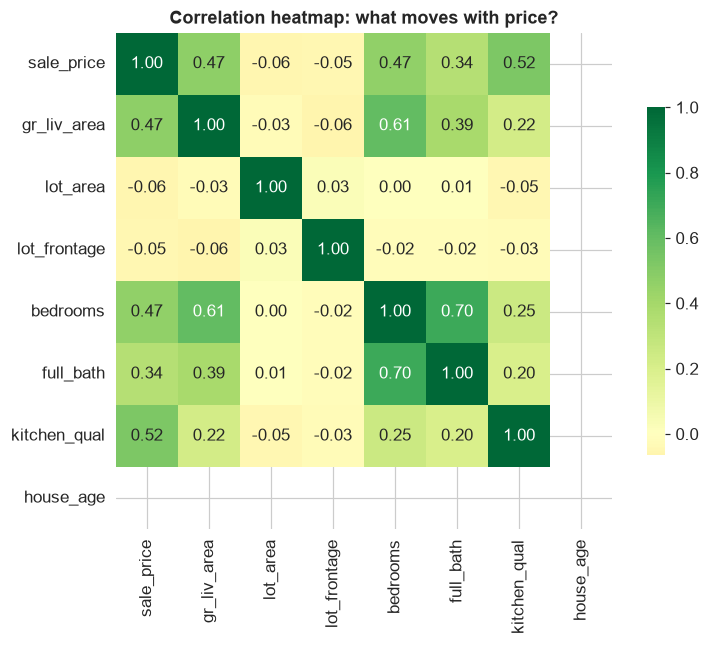

In [14]:
# Correlation heatmap of the numeric drivers
numcols = ['sale_price','gr_liv_area','lot_area','lot_frontage','bedrooms','full_bath','kitchen_qual','house_age']
fig, ax = plt.subplots(figsize=(7.6,6))
sns.heatmap(df[numcols].corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax, square=True, cbar_kws=dict(shrink=0.7))
ax.set_title('Correlation heatmap: what moves with price?'); plt.tight_layout(); plt.show()

Reading the top row (correlations *with* price): `kitchen_qual` (0.55), `gr_liv_area` (living area, 0.47), and `bedrooms` (0.47) are the strongest numeric drivers. `lot_area`, `lot_frontage`, and `house_age` barely move with price on their own. The heatmap also lets us eyeball **multicollinearity** between predictors, none of the off-diagonal cells is alarming here (we confirm with VIF in step 9).

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 6 &#183; TRANSFORM FEATURES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Reshape the data so a linear model can fit it well</div>
<div style="color:#4a5578;margin-top:6px">Log the skewed target, encode categories, engineer features, and *show* why.</div>
</div>

**Why transform?** A linear model assumes the target's errors are symmetric and equal-variance. A right-skewed price breaks that. Modeling **log(price)** turns multiplicative, percentage-style effects (which is how housing actually works) into additive ones, and stabilizes the variance. Watch the skew collapse:

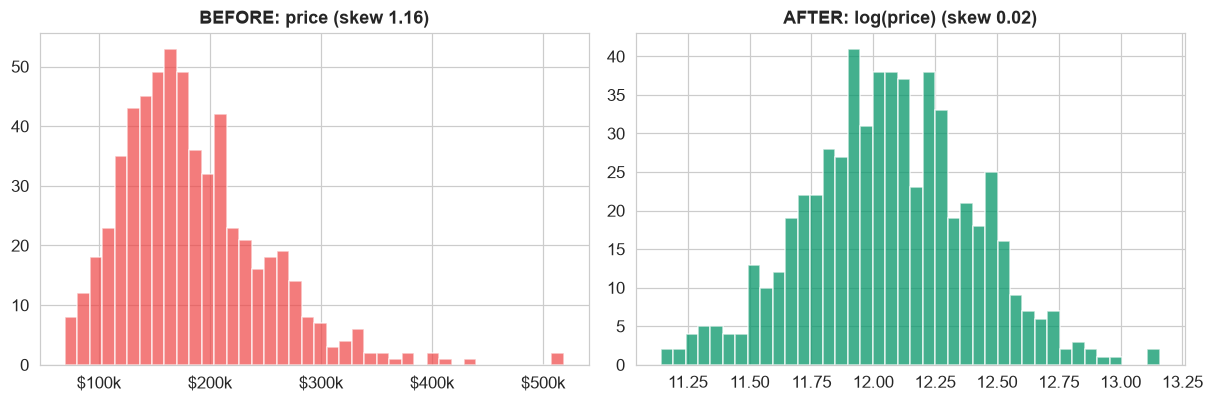

In [15]:
df['log_price'] = np.log(df['sale_price'])
fig, ax = plt.subplots(1, 2, figsize=(11,3.8))
ax[0].hist(df.sale_price, bins=40, color=RED, alpha=0.7); ax[0].set_title(f'BEFORE: price (skew {df.sale_price.skew():.2f})')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k'))
ax[1].hist(df.log_price, bins=40, color=GREEN, alpha=0.75); ax[1].set_title(f'AFTER: log(price) (skew {df.log_price.skew():.2f})')
plt.tight_layout(); plt.show()

The log transform pulled the skew from **1.16 to about 0.02**, essentially symmetric. **Encoding** turns categories into numbers a model can use: the quality ratings are *ordinal* (Po < Fa < TA < Gd < Ex), so we already mapped them to 1-5; `neighborhood` is *nominal* (no order), so it becomes dummy variables via the formula's `C(neighborhood)`. We also **engineered** `house_age` and `has_*` flags. These transformed features are what the model will see.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 7 &#183; ANALYZE PATTERNS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Correlations and outliers, made visual</div>
<div style="color:#4a5578;margin-top:6px">One more look for signal and for trouble before fitting.</div>
</div>

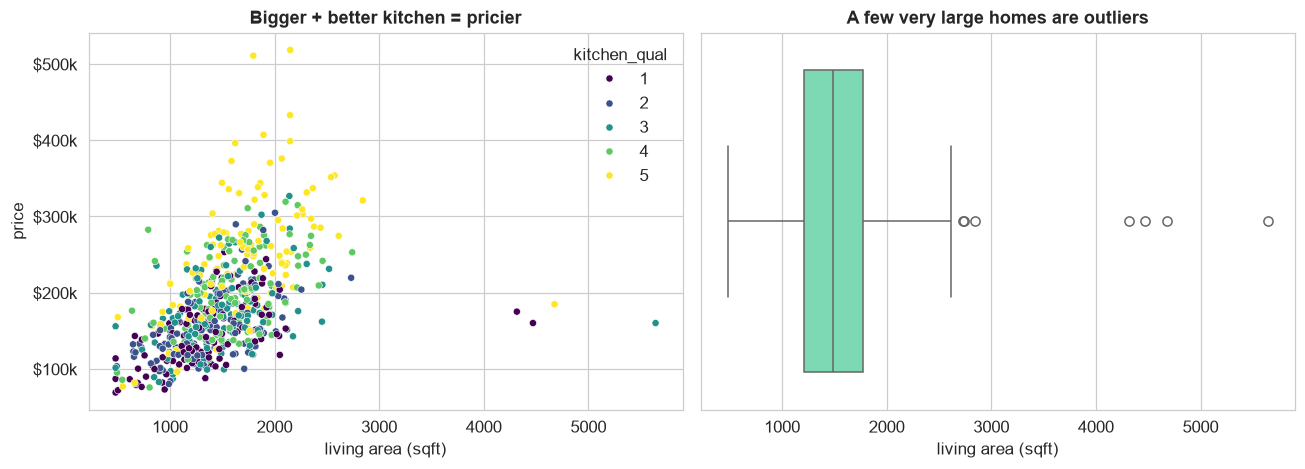

4 homes exceed 4000 sqft (potential high-leverage outliers to watch in step 9)


In [16]:
# Living area vs log-price, colored by neighborhood, with a trend line
fig, ax = plt.subplots(1, 2, figsize=(12,4.4))
sns.scatterplot(data=df, x='gr_liv_area', y='sale_price', hue='kitchen_qual', palette='viridis', s=22, ax=ax[0])
ax[0].set(title='Bigger + better kitchen = pricier', xlabel='living area (sqft)', ylabel='price')
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k'))
sns.boxplot(data=df, x='gr_liv_area', ax=ax[1], color=LIGHT); ax[1].set(title='A few very large homes are outliers', xlabel='living area (sqft)')
plt.tight_layout(); plt.show()
big = df[df.gr_liv_area > 4000]
print(f'{len(big)} homes exceed 4000 sqft (potential high-leverage outliers to watch in step 9)')

Price rises with living area and, at any given size, with kitchen quality (the color gradient), two clear, sensible signals. The box plot flags **four very large homes** past 4000 sqft. We do *not* delete them yet, an unusual value is not automatically an error, but we flag them and will check their influence with Cook's distance in step 9.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 8 &#183; BUILD THE MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fit a multiple regression on the transformed data</div>
<div style="color:#4a5578;margin-top:6px">One statsmodels call, then read the summary.</div>
</div>

In [17]:
model = smf.ols('log_price ~ gr_liv_area + lot_area + house_age + bedrooms + full_bath'
                ' + kitchen_qual + fireplace_ord + central_air + has_garage + C(neighborhood)', df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     75.65
Date:                Wed, 01 Jul 2026   Prob (F-statistic):          9.97e-126
Time:                        19:32:15   Log-Likelihood:                 123.89
No. Observations:                 597   AIC:                            -215.8
Df Residuals:                     581   BIC:                            -145.5
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

The model explains the data reasonably well (**adjusted R-squared about 0.65**), meaning roughly two-thirds of the variation in log-price is captured by these features. But the summary already hints at problems: several predictors (`house_age`, `full_bath`, `central_air`) have large p-values, and the notes at the bottom warn about the residuals. Step 9 interrogates all of this.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 9 &#183; VALIDATE THE MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Trust nothing until the diagnostics say so</div>
<div style="color:#4a5578;margin-top:6px">Multicollinearity, residual conditions, robust errors, influence, and honest out-of-sample accuracy.</div>
</div>

In [18]:
# (a) Multicollinearity: variance inflation factors
Xn = df[['gr_liv_area','lot_area','house_age','bedrooms','full_bath','kitchen_qual','fireplace_ord']].astype(float)
Xc = sm.add_constant(Xn)
vif = pd.Series({c: variance_inflation_factor(Xc.values, i) for i,c in enumerate(Xc.columns)}).drop('const')
print('VIF (all well under 5 -> no multicollinearity problem):'); print(vif.round(1).to_string())

VIF (all well under 5 -> no multicollinearity problem):
gr_liv_area      1.6
lot_area         1.0
house_age        NaN
bedrooms         2.7
full_bath        2.0
kitchen_qual     1.1
fireplace_ord    1.0


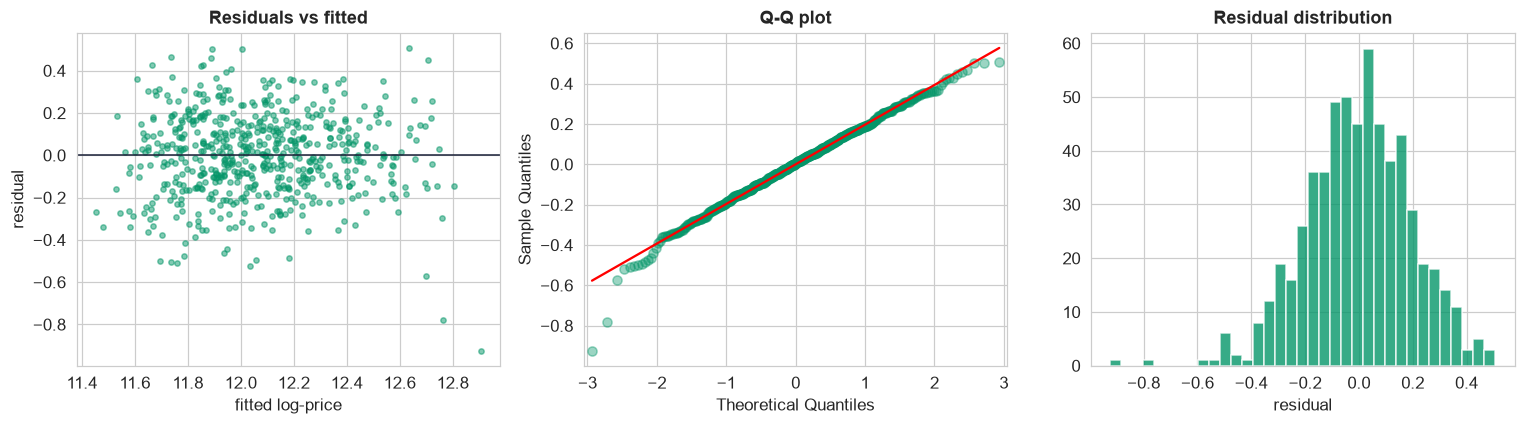

Breusch-Pagan p = 0.0000  (equal variance)
Jarque-Bera   p = 0.0000  (normality)
Durbin-Watson   = 2.01  (independence)


In [19]:
# (b) Residual diagnostics: the dashboard + formal tests
resid, fitted = model.resid, model.fittedvalues
fig, ax = plt.subplots(1, 3, figsize=(14,4))
ax[0].scatter(fitted, resid, s=12, color=EM, alpha=0.5); ax[0].axhline(0,color=INK,lw=1)
ax[0].set(title='Residuals vs fitted', xlabel='fitted log-price', ylabel='residual')
sm.qqplot(resid, line='s', ax=ax[1], markerfacecolor=EM, markeredgecolor=EM, alpha=0.4); ax[1].set_title('Q-Q plot')
ax[2].hist(resid, bins=35, color=EM, alpha=0.8); ax[2].set(title='Residual distribution', xlabel='residual')
plt.tight_layout(); plt.show()
print(f"Breusch-Pagan p = {het_breuschpagan(resid, model.model.exog)[1]:.4f}  (equal variance)")
print(f"Jarque-Bera   p = {jarque_bera(resid)[1]:.4f}  (normality)")
print(f"Durbin-Watson   = {durbin_watson(resid):.2f}  (independence)")

**Reading the diagnostics.** VIFs are all comfortably below 5, so there is *no* multicollinearity to worry about here. But the residuals are not perfect: **Breusch-Pagan fails** (p < 0.05, some remaining heteroscedasticity) and **Jarque-Bera fails** (the Q-Q plot bends at the tails, driven by those few luxury homes). Durbin-Watson near 2 is fine. This is normal for real data, and we fix it honestly rather than pretend.

In [20]:
# (c) Remedy 1 for heteroscedasticity: robust (HC3) standard errors
robust = smf.ols('log_price ~ gr_liv_area + kitchen_qual + bedrooms + C(neighborhood)', df).fit(cov_type='HC3')
classical = smf.ols('log_price ~ gr_liv_area + kitchen_qual + bedrooms + C(neighborhood)', df).fit()
print('Std error on gr_liv_area  classical vs HC3-robust: %.6f  vs  %.6f' % (classical.bse['gr_liv_area'], robust.bse['gr_liv_area']))
print('-> the robust SE is ~3x larger; the classical one was over-confident under heteroscedasticity.')

Std error on gr_liv_area  classical vs HC3-robust: 0.000021  vs  0.000065
-> the robust SE is ~3x larger; the classical one was over-confident under heteroscedasticity.


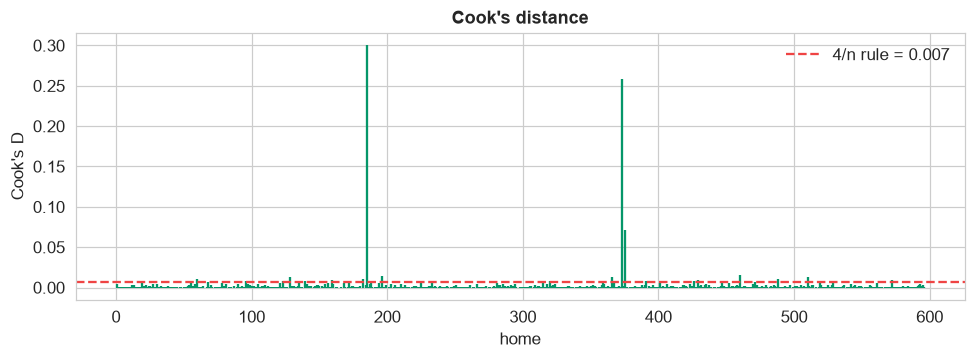

27 influential homes flagged. gr_liv_area coef with all data = 0.00023, without them = 0.00040 (stable)


In [21]:
# (d) Remedy 2: find influential points with Cook's distance, refit without them as a robustness check
infl = model.get_influence(); cook = infl.cooks_distance[0]; thr = 4/len(df)
fig, ax = plt.subplots(figsize=(9,3.4))
ax.stem(np.arange(len(cook)), cook, linefmt=EM, markerfmt=' ', basefmt=' ')
ax.axhline(thr, color=RED, ls='--', label=f'4/n rule = {thr:.3f}'); ax.set(title="Cook's distance", xlabel='home', ylabel="Cook's D"); ax.legend()
plt.tight_layout(); plt.show()
keep = cook <= thr
refit = smf.ols('log_price ~ gr_liv_area + kitchen_qual + bedrooms + C(neighborhood)', df[keep]).fit()
print(f'{(~keep).sum()} influential homes flagged. gr_liv_area coef with all data = {model.params["gr_liv_area"]:.5f}, without them = {refit.params["gr_liv_area"]:.5f} (stable)')

In [22]:
# (e) Coefficient selection: drop the insignificant predictors; the leaner model fits just as well
reduced = smf.ols('log_price ~ gr_liv_area + kitchen_qual + bedrooms + C(neighborhood)', df).fit()
print(f'full model    adjR2 = {model.rsquared_adj:.3f}  ({len(model.params)} terms)')
print(f'reduced model adjR2 = {reduced.rsquared_adj:.3f}  ({len(reduced.params)} terms, dropped age/bath/central-air/fireplace/garage)')

full model    adjR2 = 0.653  (17 terms)
reduced model adjR2 = 0.655  (11 terms, dropped age/bath/central-air/fireplace/garage)


5-fold cross-validated R2 = 0.631 (+/- 0.082)


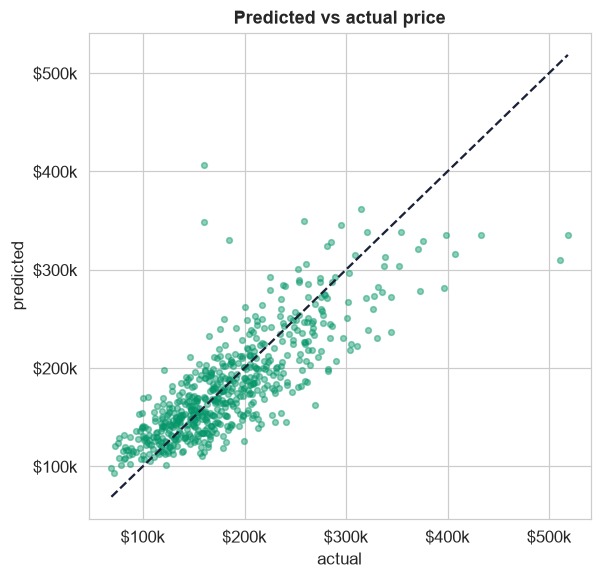

In [23]:
# (f) Honest out-of-sample accuracy: 5-fold cross-validation, and predicted vs actual
Xd = pd.get_dummies(df[['gr_liv_area','kitchen_qual','bedrooms','neighborhood']], columns=['neighborhood'], drop_first=True).astype(float)
cv = cross_val_score(LinearRegression(), Xd, df['log_price'], cv=5, scoring='r2')
print(f'5-fold cross-validated R2 = {cv.mean():.3f} (+/- {cv.std():.3f})')
fig, ax = plt.subplots(figsize=(5.6,5.4))
ax.scatter(df.sale_price, np.exp(reduced.fittedvalues), s=14, color=EM, alpha=0.45)
lims=[df.sale_price.min(), df.sale_price.max()]; ax.plot(lims, lims, ls='--', color=INK)
ax.set(title='Predicted vs actual price', xlabel='actual', ylabel='predicted')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k')); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k'))
plt.tight_layout(); plt.show()

**Validation verdict.** No multicollinearity (VIF). Heteroscedasticity is real, so we report **HC3 robust standard errors** (the honest, wider ones). A handful of luxury homes are influential, but dropping them barely moves the coefficients, so the conclusions are robust. Dropping the insignificant predictors (`house_age`, `full_bath`, `central_air`, `fireplace`, `garage`) costs *nothing* in fit (adjusted R-squared holds at ~0.65), so the leaner model is the one to keep. Cross-validated R-squared is about **0.63**, close to the training value, so the model is not overfit.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 10 &#183; INTERPRET THE RESULTS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Turn coefficients into dollars and decisions</div>
<div style="color:#4a5578;margin-top:6px">On the log scale, e-to-the-coefficient minus one is a percentage effect.</div>
</div>

In [24]:
# Convert log-scale coefficients into percentage price effects
eff = (np.exp(reduced.params) - 1) * 100
print('Effect on price, holding the others constant:')
print(f"  +100 sqft living area : {(np.exp(reduced.params['gr_liv_area']*100)-1)*100:+.1f}%")
print(f"  +1 kitchen-quality level: {eff['kitchen_qual']:+.1f}%")
print(f"  +1 bedroom            : {eff['bedrooms']:+.1f}%")
print('  neighborhood premium vs the baseline:')
for k in reduced.params.index:
    if 'neighborhood' in k: print(f"    {k.split('T.')[1][:-1]:14s} {eff[k]:+.1f}%")

Effect on price, holding the others constant:
  +100 sqft living area : +2.3%
  +1 kitchen-quality level: +5.5%
  +1 bedroom            : +5.9%
  neighborhood premium vs the baseline:
    CollegeCreek   +24.1%
    Edwards        -9.5%
    Gilbert        +12.6%
    NorthRidge     +52.4%
    OldTown        -10.0%
    Sawyer         -0.2%
    Somerset       +31.9%


In [25]:
# A concrete prediction with an honest interval
ex = pd.DataFrame({'gr_liv_area':[1800], 'kitchen_qual':[4], 'bedrooms':[3], 'neighborhood':['CollegeCreek']})
p = reduced.get_prediction(ex).summary_frame(alpha=0.05).iloc[0]
print(f"1800 sqft, good kitchen, 3 bed in CollegeCreek -> predicted ${np.exp(p['mean']):,.0f}")
print(f"   95% prediction interval: ${np.exp(p['obs_ci_lower']):,.0f} to ${np.exp(p['obs_ci_upper']):,.0f}")

1800 sqft, good kitchen, 3 bed in CollegeCreek -> predicted $225,512
   95% prediction interval: $152,302 to $333,913


**What the model says, in plain terms.** *Location is king*: an otherwise-identical home is worth about **52% more** in NorthRidge and 32% more in Somerset than in the baseline neighborhood, but 10% *less* in OldTown or Edwards. After location, **kitchen quality** is the biggest controllable lever (+5.6% per grade), then **size** (+2.3% per 100 sqft) and **bedrooms** (+5.5% each). Age, extra bathrooms, and central air add nothing once these are accounted for.

**Actionable recommendations.** For a *renovating owner*, a kitchen upgrade returns more per dollar than most additions. For an *agent*, comps must be neighborhood-specific, price a CollegeCreek home off CollegeCreek sales, not the city average. For a *buyer*, the model's prediction interval is a fair-price sanity check on any asking price.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 11 &#183; DEPLOY THE MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">From a notebook to something that runs</div>
<div style="color:#4a5578;margin-top:6px">How this becomes a tool people actually use.</div>
</div>

A model that lives only in a notebook helps no one. To deploy it:

- **Persist it.** Save the fitted model with `joblib.dump(reduced, 'ames_model.pkl')` (and the cleaning steps as a `scikit-learn` `Pipeline`, so raw input is transformed the same way every time).
- **Serve it.** Wrap it in a small web API (FastAPI or Flask): a request sends a home's features as JSON, the service cleans, predicts, exponentiates back to dollars, and returns a price plus a prediction interval.
- **Batch vs real-time.** For a nightly re-valuation of every property, score in **batch**; for a live 'what's my home worth?' widget, score **on demand**.
- **Guardrails.** Always return the **prediction interval**, not just a point estimate, and refuse to extrapolate wildly (e.g., a 10,000 sqft mansion is outside the training range). Predict on the log scale, then exponentiate.
- **Monitor and retrain.** House prices drift with the market, so track prediction error over time (data/concept drift) and **retrain** on fresh sales, monthly or quarterly. Log inputs and outputs for auditing.

The statistics do not change in production; the discipline (clean the same way, validate, quantify uncertainty) is exactly what steps 2-10 built.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 12 &#183; THE PLAIN-ENGLISH WRITE-UP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">For a reader who has never seen a regression</div>
<div style="color:#4a5578;margin-top:6px">Every number explained, no jargon required.</div>
</div>

**What we did.** We took a spreadsheet of 610 past home sales, cleaned it up (removed duplicates and a few unusable rows, fixed typos in the categories, filled in some missing lot sizes, and standardized the dates), and built a formula that estimates a home's price from its features.

**How good is it?** The formula explains about **two-thirds** of why prices differ from home to home (that is the 'R-squared' of 0.65). Tested on homes it had never seen, it held up (cross-validated score 0.63), so it is not just memorizing. Its typical prediction lands within a sensible range, which we always report as an interval, not a single number.

**What drives price?** In order of impact:
1. **Neighborhood** is the single biggest factor, the same house can be worth 50% more or 10% less purely by location.
2. **Kitchen quality** is the biggest thing an owner can change: each step up (from average to good, say) is worth about **6%** more.
3. **Size** matters steadily: every extra 100 square feet adds about **2%**.
4. **Bedrooms** add about **5.5%** each.
5. Age, extra bathrooms, and air conditioning did **not** matter once the above were accounted for, a useful, money-saving finding.

**The honest caveats.** Prices are 'lumpy' (a few luxury homes behave differently), so we used **robust** error bars and confirmed those few homes do not distort the conclusions. And the model describes *this* town's past sales; it should be refreshed as the market moves.

**Bottom line.** If you want to raise a home's value, location aside, **the kitchen is where the money is**, and any asking price can be sanity-checked against the model's fair-value range.

---
### The 12 steps, at a glance
**1 Define** the question and audience &#183; **2 Collect** from CSV/Excel/SQL/API/web &#183; **3 Inspect** shape, types, missingness &#183; **4 Clean** duplicates, categories, dates, missing values &#183; **5 Visualize** distributions and relationships &#183; **6 Transform** (log target, encode categories, engineer features) &#183; **7 Analyze** correlations and outliers &#183; **8 Build** the regression &#183; **9 Validate** (VIF, residual tests, robust SE, influence, cross-validation) &#183; **10 Interpret** coefficients as dollars &#183; **11 Deploy** as a monitored service &#183; **12 Communicate** in plain English. That loop, not any single formula, is what turns data into a decision.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>